### Submission 1 Supp. Pre vs post stopping distance supplementary: do histogram and stats

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pickle
import pandas as pd

In [75]:
from spyglass.shijiegu.changeOfMind_figures.figure_prepost_supp import get_prepost_normalized_histogram, plot_prepost_normalized_histogram

In [90]:
list_of_days_animals = {}
success_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']

In [4]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4'
decoder_type = "run_time"
hpd_flag = False
decoder_type = "run_time"
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4'

In [52]:
loaded_data_all_days = {}
for animal in ["eliot", "molly", "julio", "klein", "lewis"]:
    file_path = f"{output_folder}/prepost_{decoder_type}_{animal}_{hpd_flag}.pickle"
    with open(file_path, 'rb') as file:
        loaded_data_all_days[animal] = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_eliot_False.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_molly_False.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_julio_False.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_klein_False.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost_run_time_lewis_False.pickle


In [214]:
counts_forward, counts_behind, mean_forward, sd_forward , mean_behind, sd_behind = {}, {} , {}, {}, {}, {} #sd is standard error

for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    (bins, counts_forward[animal], counts_behind[animal],
     mean_forward[animal], sd_forward[animal], mean_behind[animal], sd_behind[animal]) = get_prepost_normalized_histogram(
        animal, list_of_days_animals, loaded_data_all_days[animal], SD_threshold = 6)

[17:58:38][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[17:58:38][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


working on animal  molly  with SD threshold  6
20220416
20220417
20220418
20220419
20220420
working on animal  eliot  with SD threshold  6
20221018
20221019
20221020
20221021
20221022
20221023


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


20221024
20221025
20221026
working on animal  julio  with SD threshold  6
20230731
20230801
20230802
20230803


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


20230804
20230805
20230806
20230807
20230808
20230809
20230810
20230811
working on animal  klein  with SD threshold  6
20231101
20231102
20231103
20231104


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


20231105
20231106
20231107


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


20231108
working on animal  lewis  with SD threshold  6
20240105
20240106
20240107
20240108
20240109
20240110


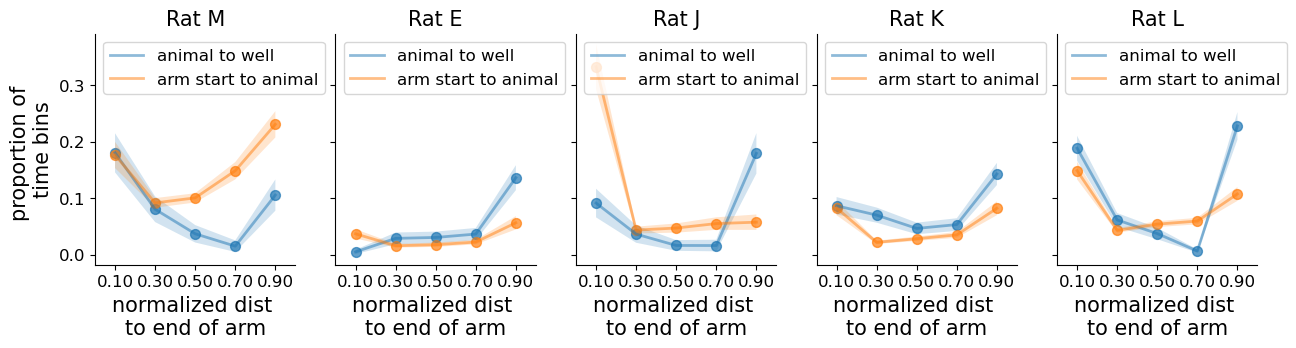

In [333]:
fig, axes = plt.subplots(1,5,figsize=(15,3), sharey = True)

animal_ind = 0
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    ax = axes[animal_ind]

    plot_prepost_normalized_histogram(animal, bins, mean_forward[animal], sd_forward[animal], mean_behind[animal], sd_behind[animal],
                                      ax)

    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_prepost_histogram.pdf"
    fig.savefig(file_path, format="pdf", bbox_inches="tight")

    animal_ind += 1

## Mixed linear effect

#### forward

In [317]:
def do_glm(counts_forward, animals, bins_GLM):
    rng = np.random.default_rng(seed=2026)
    GLM_x = []
    GLM_y = []
    for animal in animals:
        GLM_x_animal = []
        GLM_y_animal = []
        counts = counts_forward[animal]
        
        for bin_ind in range(len(bins_GLM)):
            
            prop_animal_arm = counts[:,bin_ind]
            prop_animal_arm = prop_animal_arm[prop_animal_arm > 0]
            N = len(prop_animal_arm)
    
            # add arm catogory
            bin_catogory = np.array([_ == bin_ind for _ in bins_GLM]).reshape((1,-1)).astype("int")
            X_bin_catogory = ml.repmat(bin_catogory, N, 1)
    
            Y_animal_arm = prop_animal_arm.reshape((-1,1))
    
            GLM_x_animal.append(X_bin_catogory)
            GLM_y_animal.append(Y_animal_arm)
    
        # concat across arms
        GLM_x_animal = np.vstack(GLM_x_animal)
        GLM_y_animal = np.vstack(GLM_y_animal)
        
        # add animal catogory
        animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
        X_animal_category = ml.repmat(animal_category, np.shape(GLM_x_animal)[0], 1)
        X_animal = np.hstack((X_animal_category, GLM_x_animal)).astype("float")
        Y_animal = GLM_y_animal.astype("float")
    
        GLM_x.append(X_animal)
        GLM_y.append(Y_animal)
    GLM_x = np.vstack(GLM_x)
    GLM_y = np.vstack(GLM_y)

    feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
    feature_dict["bin animal"] = GLM_x[:,len(animals)]
    feature_dict["bin 2"] = GLM_x[:,(len(animals)+1)]
    feature_dict["bin 3"] = GLM_x[:,(len(animals)+2)]
    feature_dict["bin 4"] = GLM_x[:,(len(animals)+3)]
    feature_dict["bin end"] = GLM_x[:,(len(animals)+4)]
    
    X = pd.DataFrame(feature_dict)
    if len(animals) > 0:
        X = sm.add_constant(X)
    y = GLM_y
    
    """a) Mixed Linear Effect"""
    ols_model = sm.OLS(np.log(y + 0.0001),X)
    ols_result1 = ols_model.fit()
    
    print("Mixed Linear Effect \n",ols_result1.summary())

    return ols_result1

    

In [318]:
import numpy.matlib as ml
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

In [319]:
bins_GLM = np.arange(len(bins)-1) #DO NOT CHANGE, AS IT IS SET IN THE LAST CELL

animals = ["julio","lewis","eliot","molly","klein"]




### plot parameters

In [320]:
from spyglass.shijiegu.changeOfMind_figures.dynamic_home_arm import (model2numbers)

In [342]:
def plot_coefficients(ols_result1, ols_result2, animals):
    fig, axes = plt.subplots(1,2,figsize=(5, 3),sharey = True)
    if len(animals) > 1:
        mixed = 1
    else:
        mixed = 0
    
    for m in [0,1]:
        annotations = []
        if m == 0:
            coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
            coef_est = np.exp(coef_est)
            CI = np.exp(CI)
            color = "C0"
        else:
            coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result2)
            coef_est = np.exp(coef_est)
            CI = np.exp(CI)
            color = "C1"
    
    
        for (ind,coef_name) in enumerate(coef_names):
            axes[m].scatter(ind, coef_est[ind], color = color)
            axes[m].plot([ind,ind],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = color)
        
        for coef_ind in range(len(pvalues)):
            pvalue = pvalues[coef_ind]
            if pvalue < 0.05:
                annotations.append((coef_ind, coef_ind, np.round(pvalue, 5)))
        
        starbars.draw_annotation(annotations, ax = axes[m])
        
        axes[m].set_xticks(np.arange(len(coef_names)))
        axes[m].set_xticklabels(coef_names, rotation=45)
        if m == 0:
            if mixed:
                axes[m].set_title(f"for decode between \n animal and well")
            else:
                axes[m].set_title(f"Rat {animal[0].upper()}")
        else:
            if mixed:
                axes[m].set_title(f"for decode between \n animal and start of arm")
            else:
                axes[m].set_title(f"Rat {animal[0].upper()}")
        axes[m].set_ylabel("Fold change")
        axes[m].axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
        #axes[m].set_ylim([0.5,3])
        #axes[m].set_xlim([-0.3,3.3])
    
       
        axes[m].spines[['right', 'top']].set_visible(False)
        
    fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

    if mixed:
        file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_prepost_histogram_mixedGLM.pdf"
    else:
        file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_prepost_histogram_GLM_{animals[0]}.pdf"
    plt.savefig(file_path,dpi=300,bbox_inches='tight')

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                     40.31
Date:                Mon, 18 May 2026   Prob (F-statistic):           6.29e-54
Time:                        21:28:10   Log-Likelihood:                -1407.9
No. Observations:                 789   AIC:                             2834.
Df Residuals:                     780   BIC:                             2876.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2074      0.0

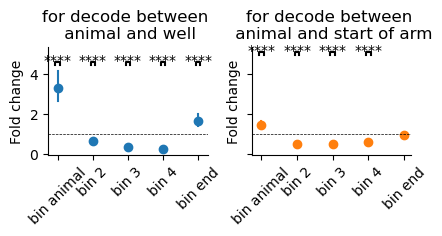

In [343]:
animals = ["julio","lewis","eliot","molly","klein"]
ols_result1 = do_glm(counts_forward, animals, bins_GLM) #forward
ols_result2 = do_glm(counts_behind, animals, bins_GLM) #behind
plot_coefficients(ols_result1, ols_result2, animals)

In [336]:
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)

In [345]:
np.exp(coef_est)

array([3.30749186, 0.62945957, 0.32588888, 0.26408627, 1.66856973])

In [346]:
np.exp(CI)

,0,1
bin animal,2.651170,4.126292
bin 2,0.512296,0.773419
bin 3,0.261878,0.405546
bin 4,0.208166,0.335029
bin end,1.403765,1.983328


In [337]:
pvalues

bin animal    1.105134e-24
bin 2         1.168878e-05
bin 3         1.738929e-22
bin 4         3.358564e-26
bin end       8.809158e-09
dtype: float64

### individual animals

julio
Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     10.43
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.59e-06
Time:                        21:28:57   Log-Likelihood:                -108.68
No. Observations:                  67   AIC:                             227.4
Df Residuals:                      62   BIC:                             238.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Rat J         -1.4663   

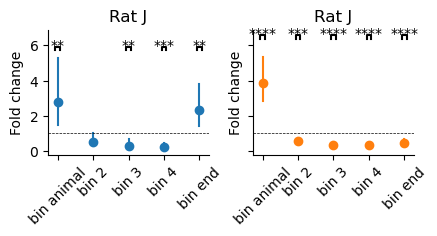

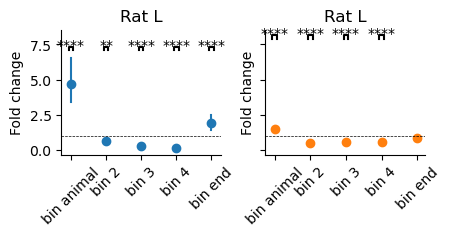

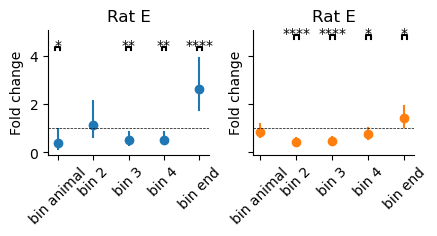

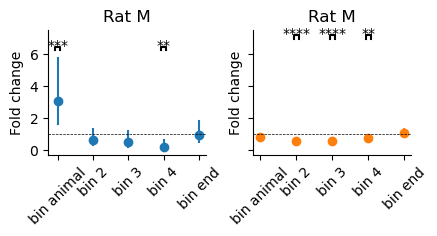

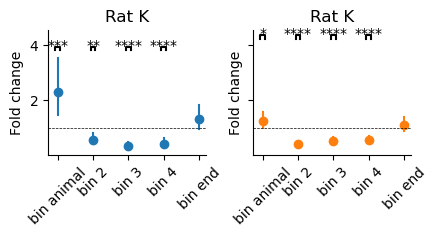

In [344]:
bins_GLM = np.arange(len(bins)-1) #DO NOT CHANGE, AS IT IS SET IN THE LAST CELL

for animal in ["julio","lewis","eliot","molly","klein"]:
    print(animal)
    ols_result1 = do_glm(counts_forward, [animal], bins_GLM) #forward
    ols_result2 = do_glm(counts_behind, [animal], bins_GLM) #behind
    plot_coefficients(ols_result1, ols_result2, [animal])